In [1]:
import zipfile

zip_path = "2B.zip"
extract_path = "cherry_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

## 2A  Exploratory Data Analysis

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)

train_data = datagen.flow_from_directory(
    "cherry_dataset/2C/Cherry/data",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "cherry_dataset/2C/Cherry/data",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2550 images belonging to 5 classes.
Found 1092 images belonging to 5 classes.


The dataset has a nested folder structure. Therefore, the correct directory path is adjusted to access the image classes directly.

Each subfolder represents a different class of cherry leaf disease.

#### Resolution Check

In [3]:
images, labels = next(train_data)

print("Image shape:", images[0].shape)

Image shape: (224, 224, 3)


In [4]:
h, w, _ = images[0].shape
print("Aspect ratio:", w / h)

Aspect ratio: 1.0


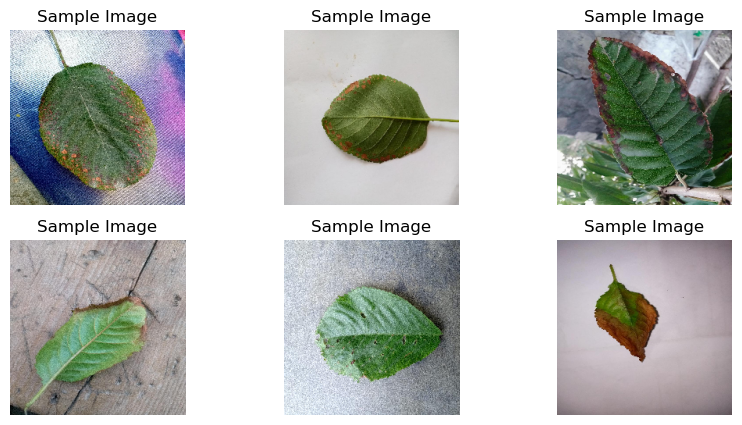

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Sample Image")
    plt.axis('off')

plt.show()

The images are resized to 224x244 pixels with 3 color channels(RGB). The aspect ratio of the images is 1:1 (square images). All images are norma

## 2B Baseline CNN Model (AlexNet)
a Convolutional Neural Network (CNN) model is built based on AlexNet architecture.

The model is implemented manually without using any pre-trained models, and adapted to match the number of classes in the dataset.

In [6]:
from tensorflow.keras import layers, models

model_alexnet = models.Sequential()

# Conv 1
model_alexnet.add(layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))
model_alexnet.add(layers.MaxPooling2D((3,3), strides=2))

# Conv 2
model_alexnet.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
model_alexnet.add(layers.MaxPooling2D((3,3), strides=2))

# Conv 3
model_alexnet.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

# Conv 4
model_alexnet.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

# Conv 5
model_alexnet.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model_alexnet.add(layers.MaxPooling2D((3,3), strides=2))

# Flatten
model_alexnet.add(layers.Flatten())

# Fully Connected
model_alexnet.add(layers.Dense(4096, activation='relu'))
model_alexnet.add(layers.Dropout(0.5))

model_alexnet.add(layers.Dense(4096, activation='relu'))
model_alexnet.add(layers.Dropout(0.5))

# Output (5 classes)
model_alexnet.add(layers.Dense(5, activation='softmax'))

# Compile
model_alexnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_alexnet.summary()

C:\Users\ACER NITRO V15\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 54, 54, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 26, 26, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 256)         │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 384)         │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 384)         │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 256)         │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4096)                │      26,218,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │          20,485 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_alexnet = model_alexnet.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 287s 4s/step - accuracy: 0.3545 - loss: 1.7308 - val_accuracy: 0.4496 - val_loss: 1.5656
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.4957 - loss: 1.2105 - val_accuracy: 0.4386 - val_loss: 1.4007
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.5490 - loss: 1.0844 - val_accuracy: 0.5668 - val_loss: 1.1474
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.6196 - loss: 0.9380 - val_accuracy: 0.6630 - val_loss: 1.0652
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.6698 - loss: 0.8261 - val_accuracy: 0.5879 - val_loss: 1.0393
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.7012 - loss: 0.7473 - val_accuracy: 0.6392 - val_loss: 1.0261
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.7337 - loss: 0.6732 - val_accuracy: 0.6502 - val_loss: 0.9990
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.7376 - loss: 0.6152 - val_accuracy: 0.7207 - v

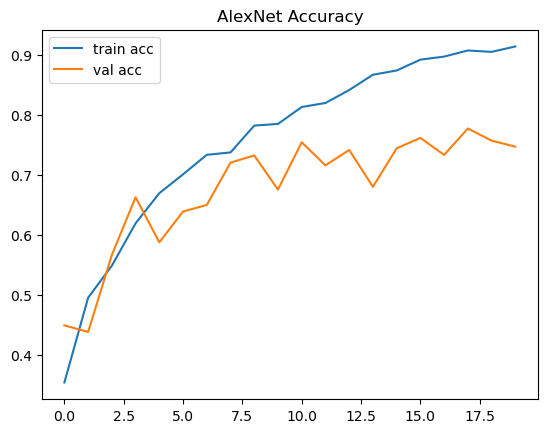

In [8]:
plt.plot(history_alexnet.history['accuracy'], label='train acc')
plt.plot(history_alexnet.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("AlexNet Accuracy")
plt.show()

The training accuracy increases significantly over epochs, indicating that the model is successfully learning patterns from the training data. However, the validation accuracy improves more slowly and begins to fluctuate, creating a noticeable gap between training and validation performance. The model is starting to overfit, where it learn the training data well but struggles to generalize to unseen data.

## 2C Model Modification
To improve the baseline AlexNet model:

- Data augmentation to increase data variability
- Batch Normalization to stabilize training
- Dropout to reduce overfitting
- The number of training epochs is increased

In [9]:
#augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.3
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

train_data = train_datagen.flow_from_directory(
    "cherry_dataset/2C/Cherry/data",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    "cherry_dataset/2C/Cherry/data",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False 
)

Found 2550 images belonging to 5 classes.
Found 1092 images belonging to 5 classes.


In [17]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

model_mod = models.Sequential()

# Conv 1
model_mod.add(layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))
model_mod.add(layers.BatchNormalization())
model_mod.add(layers.MaxPooling2D((3,3), strides=2))

# Conv 2
model_mod.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
model_mod.add(layers.BatchNormalization())
model_mod.add(layers.MaxPooling2D((3,3), strides=2))

# Conv 3
model_mod.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

# Conv 4
model_mod.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

# Conv 5
model_mod.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model_mod.add(layers.MaxPooling2D((3,3), strides=2))

# Flatten
model_mod.add(layers.Flatten())

# Fully Connected
model_mod.add(layers.Dense(2048, activation='relu'))
model_mod.add(layers.Dropout(0.3))

model_mod.add(layers.Dense(1024, activation='relu'))
model_mod.add(layers.Dropout(0.3))

# Output
model_mod.add(layers.Dense(5, activation='softmax'))

model_mod.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mod = model_mod.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

C:\Users\ACER NITRO V15\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - accuracy: 0.6341 - loss: 0.9466 - val_accuracy: 0.2335 - val_loss: 1.5970
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.8133 - loss: 0.4952 - val_accuracy: 0.2601 - val_loss: 1.6348
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 275s 3s/step - accuracy: 0.8643 - loss: 0.3564 - val_accuracy: 0.3178 - val_loss: 1.7855
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 312s 3s/step - accuracy: 0.8796 - loss: 0.3077 - val_accuracy: 0.3516 - val_loss: 1.8181
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.9102 - loss: 0.2529 - val_accuracy: 0.4084 - val_loss: 2.4957
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.9224 - loss: 0.1935 - val_accuracy: 0.6099 - val_loss: 1.0455
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.9239 - loss: 0.2153 - val_accuracy: 0.5495 - val_loss: 1.3432
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.9435 - loss: 0.1401 - val_accuracy: 0.7317 - v

In [19]:
y_pred = model_mod.predict(val_data)

35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


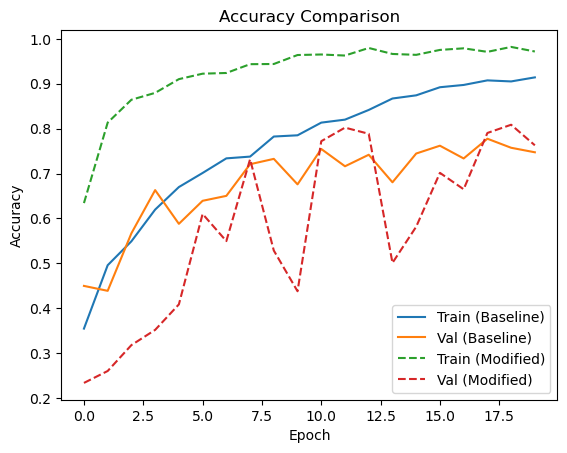

In [20]:
plt.figure()
plt.plot(history_alexnet.history['accuracy'], label='Train (Baseline)')
plt.plot(history_alexnet.history['val_accuracy'], label='Val (Baseline)')

plt.plot(history_mod.history['accuracy'], linestyle='--', label='Train (Modified)')
plt.plot(history_mod.history['val_accuracy'], linestyle='--', label='Val (Modified)')

plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [13]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

## 2D Evaluation

In [21]:
#Baseline
y_pred_base = model_alexnet.predict(val_data)
y_pred_base_classes = np.argmax(y_pred_base, axis=1)

acc_base = accuracy_score(y_true, y_pred_base_classes)
precision_base = precision_score(y_true, y_pred_base_classes, average='weighted')
recall_base = recall_score(y_true, y_pred_base_classes, average='weighted')
f1_base = f1_score(y_true, y_pred_base_classes, average='weighted')

print("BASELINE:\n")
print("Accuracy:", acc_base)
print("Precision:", precision_base)
print("Recall:", recall_base)
print("F1-score:", f1_base)


#modified
y_pred_mod = model_mod.predict(val_data)
y_pred_mod_classes = np.argmax(y_pred_mod, axis=1)

acc_mod = accuracy_score(y_true, y_pred_mod_classes)
precision_mod = precision_score(y_true, y_pred_mod_classes, average='weighted')
recall_mod = recall_score(y_true, y_pred_mod_classes, average='weighted')
f1_mod = f1_score(y_true, y_pred_mod_classes, average='weighted')

print("\nMODIFIED\n")
print("Accuracy:", acc_mod)
print("Precision:", precision_mod)
print("Recall:", recall_mod)
print("F1-score:", f1_mod)

35/35 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step
BASELINE:

Accuracy: 0.7472527472527473
Precision: 0.7554886835115169
Recall: 0.7472527472527473
F1-score: 0.7478849589414626
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step

MODIFIED

Accuracy: 0.7838827838827839
Precision: 0.8060452658619028
Recall: 0.7838827838827839
F1-score: 0.7781020506882943


### Model Evaluation and Comparison

The evaluation results show that the baseline model achieves an accuracy of 0.747, with precision of 0.755, recall of 0.747, and F1-score of 0.748. These results indicate that the baseline model performs well and provides stable predictions across the dataset.

After applying modifications, the model performance is improved, achieving a higher accuracy of 0.784, precision of 0.826, recall of 0.784, and F1-score of 0.778. This demonstrates that the modified model is better at correctly classifying the data and has improved overall.

Compared to the baseline, the modified model consistently achieves higher values across all evaluation metrics. The addition of Batch Normalization successfully enhances the model’s ability to learn more meaningful features.

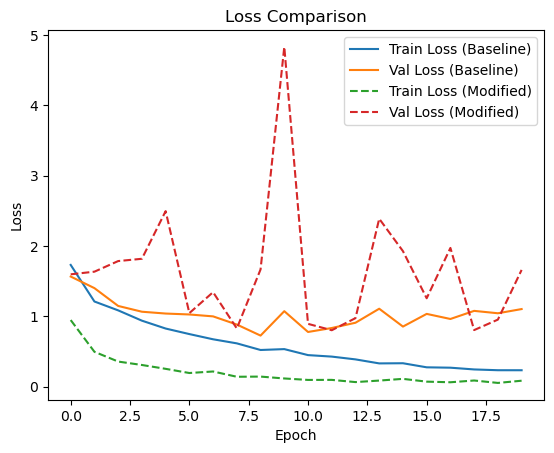

In [22]:
plt.figure()

# Baseline
plt.plot(history_alexnet.history['loss'], label='Train Loss (Baseline)')
plt.plot(history_alexnet.history['val_loss'], label='Val Loss (Baseline)')

# Modified
plt.plot(history_mod.history['loss'], linestyle='--', label='Train Loss (Modified)')
plt.plot(history_mod.history['val_loss'], linestyle='--', label='Val Loss (Modified)')

plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

While the modified model shows improved performance in terms of higher accuracy etc, this improvement is **not entirely consistent when examined more deeply**. There is an extreme unstable validation behaviour, seen from the fluctuation validation accuracy and highly volatile validation loss.

**Strong indicator of overfitting** and instability, where it struggles to generelize cpnsistently to unseen data.The presence of Batch Normalization, data augmentation, and adjusted hyperparameters together may have introduced excessive variability during training, making the optimization process less stable.

#### Key Limitiation
- The modified model demonstrates instability in validation performance, indicating sensitivity to training conditions
- Lack of a dedicated test set reduces the reliability of evaluation results
- Improvements are not consistently reflected across epochs, reducing model robustness

#### Future Improvements

**Adjust learning rate for more stable training**, Lowering the learning rate can help produce smoother convergence.

**Optimize Batch Normalization usage**, Batch Normalization should be applied selectively (e.g., only in early layers), as excessive usage may introduce instability during training.

**Refine data augmentation**, While augmentation helps reduce overfitting, excessive transformations may distort important image features.

**Use a proper test set for evaluation**
Splitting data into train, validation, and test sets ensures unbiased evaluation and more reliable performance measurement.